# 📊 Analisis Regresi Linier - Forecasting Penjualan
**Dataset:** Dataset_Forecasting_ARIMA_Lengkap1.xlsx  
**Tujuan:** Memprediksi Total_Sales menggunakan fitur-fitur yang relevan dengan algoritma Regresi Linier

## 1. Import Library

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✅ Semua library berhasil di-import')

✅ Semua library berhasil di-import


## 2. Load & Preprocessing Data

In [31]:
# Load data dari sheet Pivot_Harian_ARIMA
import datetime

df_raw = pd.read_excel('Dataset_Forecasting_ARIMA_Lengkap1.xlsx', sheet_name='Pivot_Harian_ARIMA')

# Filter hanya baris dengan tanggal valid (datetime)
df = df_raw[df_raw['Date'].apply(lambda x: isinstance(x, datetime.datetime))].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'📅 Rentang Tanggal : {df["Date"].min().date()} s/d {df["Date"].max().date()}')
print(f'📊 Jumlah Baris    : {len(df)}')
print(f'📋 Jumlah Kolom    : {len(df.columns)}')
df.head()

📅 Rentang Tanggal : 2025-01-01 s/d 2025-12-31
📊 Jumlah Baris    : 365
📋 Jumlah Kolom    : 39


,Date,AERIS10,BB 10,BB 30,BR45,BR75,CC,CNF,CNF 10,CNF 100,...,MYB,MYB 10,MYB 100,NB,TC,TC 10,TC 250,TEETH10,TP,Total_Sales
0,2025-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-01-02,0.0,0.0,1.0,0.0,0.0,0.0,3.0,14.0,0.0,...,0.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,42.0
2,2025-01-03,0.0,1.0,0.0,0.0,0.0,0.0,18.0,45.0,0.0,...,0.0,0.0,0.0,2.0,3.0,6.0,1.0,0.0,0.0,117.0
3,2025-01-04,0.0,0.0,0.0,0.0,0.0,0.0,8.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0
4,2025-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
# Informasi tipe data dan missing values
print('=== INFO DATASET ===')
df.info()
print(f'\nMissing Values per Kolom:')
print(df.isnull().sum()[df.isnull().sum() > 0])

=== INFO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 39 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         365 non-null    datetime64[us]
 1   AERIS10      365 non-null    float64       
 2   BB 10        365 non-null    float64       
 3   BB 30        365 non-null    float64       
 4   BR45         365 non-null    float64       
 5   BR75         365 non-null    float64       
 6   CC           365 non-null    float64       
 7   CNF          365 non-null    float64       
 8   CNF 10       365 non-null    float64       
 9   CNF 100      365 non-null    float64       
 10  CNF 250      365 non-null    float64       
 11  DS           365 non-null    float64       
 12  DS 10        365 non-null    float64       
 13  DS 100       365 non-null    float64       
 14  DS 250       365 non-null    float64       
 15  EC45         365 non-null    float64       
 16

In [33]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF Total_Sales ===')
print(df['Total_Sales'].describe())
print(f'\nJumlah hari dengan penjualan > 0: {(df["Total_Sales"] > 0).sum()} dari {len(df)} hari')

=== STATISTIK DESKRIPTIF Total_Sales ===
count    365.000000
mean      14.353425
std       36.302280
min        0.000000
25%        0.000000
50%        3.000000
75%       13.000000
max      452.000000
Name: Total_Sales, dtype: float64

Jumlah hari dengan penjualan > 0: 272 dari 365 hari


## 3. Feature Engineering

In [34]:
# Buat fitur-fitur berbasis waktu
df['DayOfYear']   = df['Date'].dt.dayofyear
df['DayOfWeek']   = df['Date'].dt.dayofweek       # 0=Senin, 6=Minggu
df['DayOfMonth']  = df['Date'].dt.day
df['Month']       = df['Date'].dt.month
df['WeekOfYear']  = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter']     = df['Date'].dt.quarter
df['IsWeekend']   = (df['DayOfWeek'] >= 5).astype(int)

# Fitur lag (penjualan hari sebelumnya)
df['Lag1']  = df['Total_Sales'].shift(1)
df['Lag7']  = df['Total_Sales'].shift(7)
df['Lag14'] = df['Total_Sales'].shift(14)

# Fitur rolling mean
df['RollingMean7']  = df['Total_Sales'].shift(1).rolling(window=7).mean()
df['RollingMean14'] = df['Total_Sales'].shift(1).rolling(window=14).mean()
df['RollingStd7']   = df['Total_Sales'].shift(1).rolling(window=7).std()

# Trend linier (nomor urut hari)
df['Trend'] = np.arange(len(df))

# Top produk sebagai fitur tambahan
top_products = ['CNF', 'CNF 10', 'DS 10', 'DS', 'TC 10', 'JOY 10', 'IB 10', 'GF 10']

# Hapus baris dengan NaN akibat lag/rolling
df_model = df.dropna().reset_index(drop=True)

print(f'✅ Feature engineering selesai')
print(f'   Baris tersedia untuk modeling: {len(df_model)}')
print(f'   Fitur baru yang dibuat: DayOfYear, DayOfWeek, DayOfMonth, Month, WeekOfYear,'
      f' Quarter, IsWeekend, Lag1, Lag7, Lag14, RollingMean7, RollingMean14, RollingStd7, Trend')

✅ Feature engineering selesai
   Baris tersedia untuk modeling: 351
   Fitur baru yang dibuat: DayOfYear, DayOfWeek, DayOfMonth, Month, WeekOfYear, Quarter, IsWeekend, Lag1, Lag7, Lag14, RollingMean7, RollingMean14, RollingStd7, Trend


## 4. Eksplorasi Data (EDA)

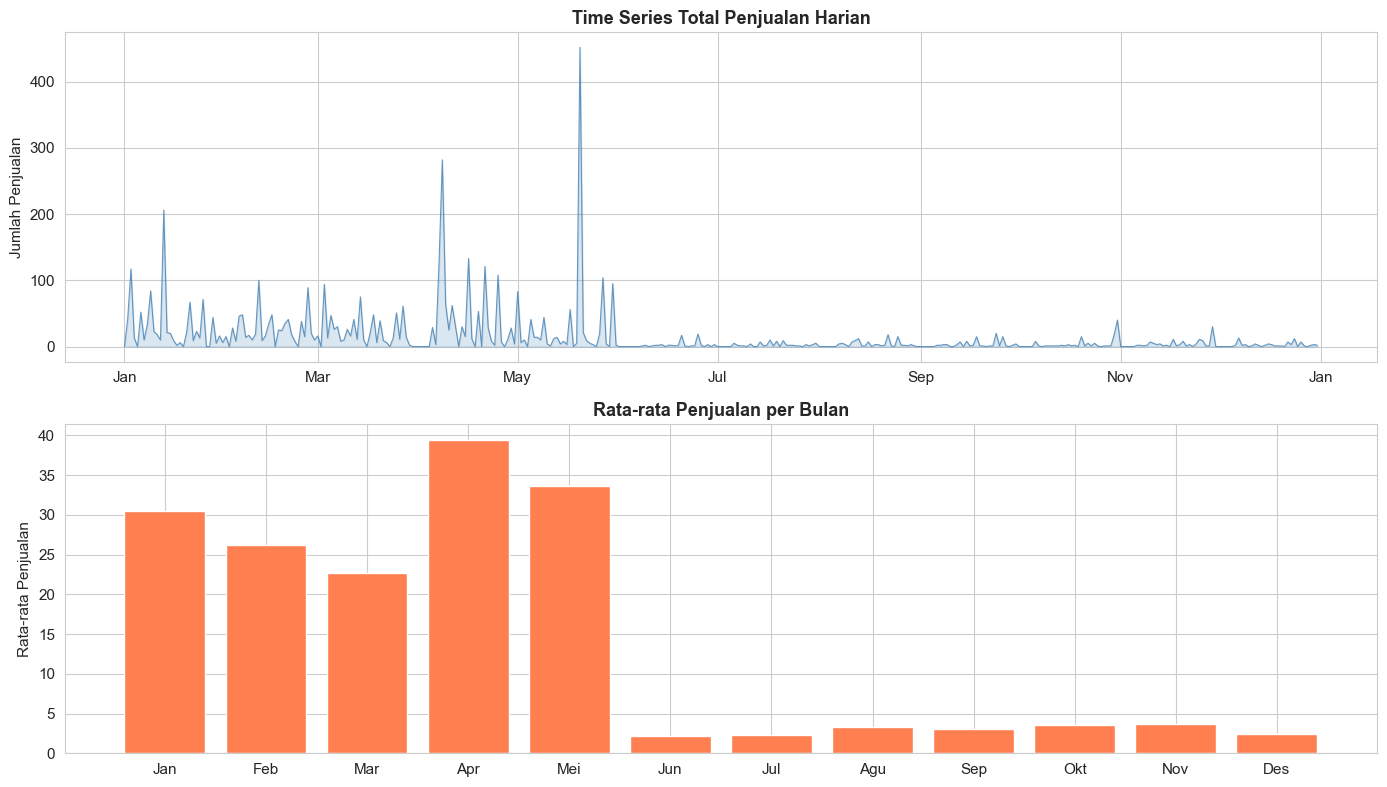

In [35]:
# Plot time series Total_Sales
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df['Date'], df['Total_Sales'], color='steelblue', linewidth=0.8, alpha=0.8)
axes[0].fill_between(df['Date'], df['Total_Sales'], alpha=0.2, color='steelblue')
axes[0].set_title('Time Series Total Penjualan Harian', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Penjualan')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Plot rata-rata penjualan per bulan
monthly = df.groupby('Month')['Total_Sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
axes[1].bar(month_names, monthly.values, color='coral', edgecolor='white')
axes[1].set_title('Rata-rata Penjualan per Bulan', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Rata-rata Penjualan')

plt.tight_layout()
plt.show()

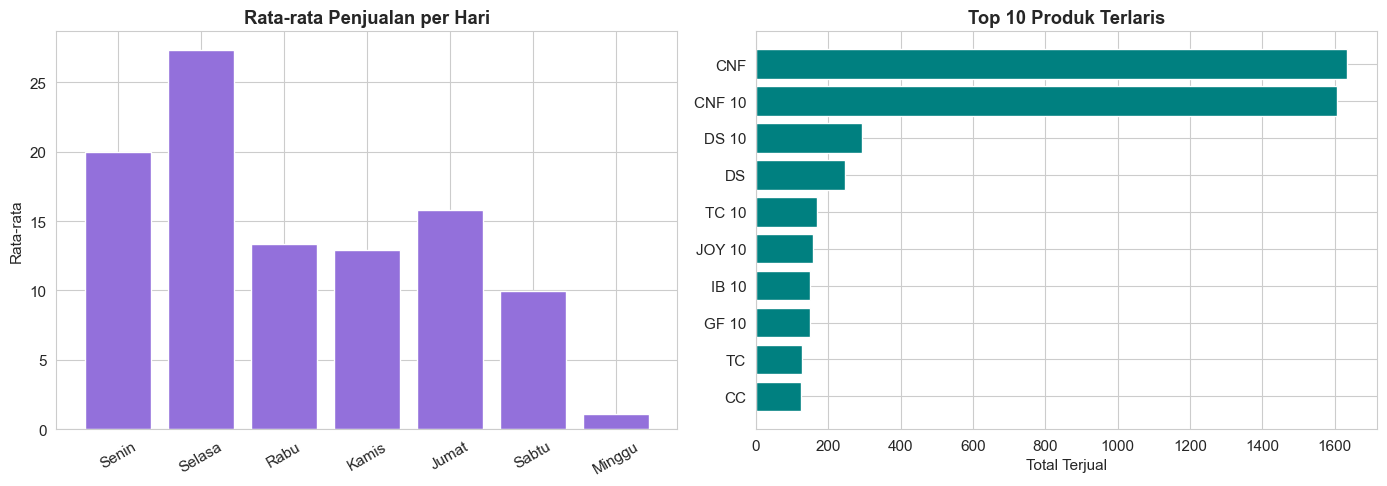

In [36]:
# Distribusi penjualan per hari dalam seminggu
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_names = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
daily_avg = df.groupby('DayOfWeek')['Total_Sales'].mean()
axes[0].bar(day_names, daily_avg.values, color='mediumpurple', edgecolor='white')
axes[0].set_title('Rata-rata Penjualan per Hari', fontweight='bold')
axes[0].set_ylabel('Rata-rata')
axes[0].tick_params(axis='x', rotation=30)

# Top 10 produk
prod_cols = [c for c in df.columns if c not in ['Date','Total_Sales','DayOfYear','DayOfWeek',
             'DayOfMonth','Month','WeekOfYear','Quarter','IsWeekend','Lag1','Lag7','Lag14',
             'RollingMean7','RollingMean14','RollingStd7','Trend']]
top10 = df[prod_cols].sum().sort_values(ascending=True).tail(10)
axes[1].barh(top10.index, top10.values, color='teal', edgecolor='white')
axes[1].set_title('Top 10 Produk Terlaris', fontweight='bold')
axes[1].set_xlabel('Total Terjual')

plt.tight_layout()
plt.show()

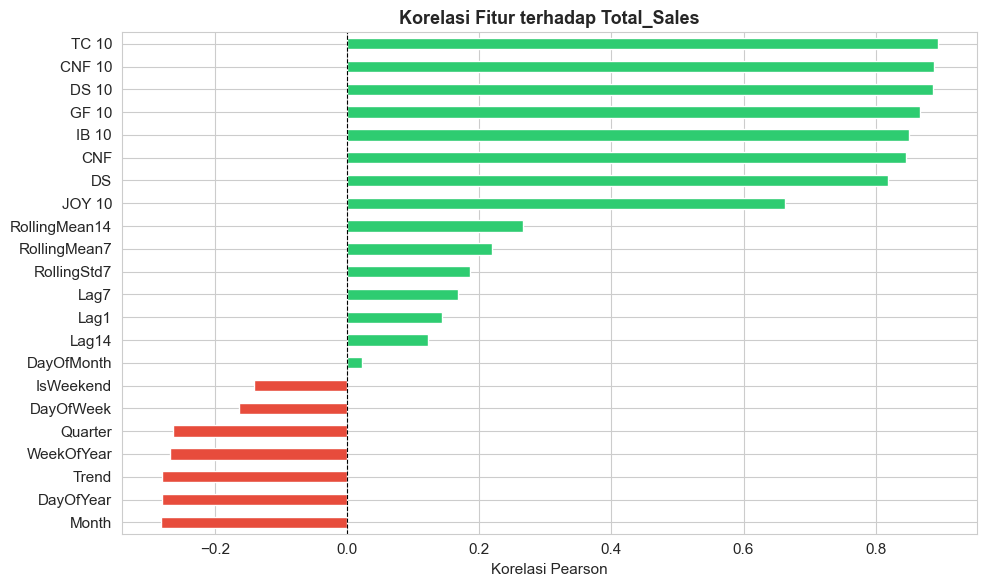


Top 5 Fitur Korelasi Tertinggi:
TC 10     0.894402
CNF 10    0.888269
DS 10     0.886553
GF 10     0.866573
IB 10     0.850948
Name: Total_Sales, dtype: float64


In [37]:
# Korelasi fitur dengan Total_Sales
feature_cols = ['DayOfYear','DayOfWeek','DayOfMonth','Month','WeekOfYear','Quarter',
                'IsWeekend','Lag1','Lag7','Lag14','RollingMean7','RollingMean14',
                'RollingStd7','Trend'] + top_products

corr = df_model[feature_cols + ['Total_Sales']].corr()['Total_Sales'].drop('Total_Sales').sort_values()

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr.values]
corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Korelasi Fitur terhadap Total_Sales', fontsize=13, fontweight='bold')
plt.xlabel('Korelasi Pearson')
plt.tight_layout()
plt.show()

print('\nTop 5 Fitur Korelasi Tertinggi:')
print(corr.abs().sort_values(ascending=False).head(5))

## 5. Persiapan Data untuk Modeling

In [38]:
# Definisi fitur dan target
feature_cols = ['DayOfYear','DayOfWeek','DayOfMonth','Month','WeekOfYear','Quarter',
                'IsWeekend','Lag1','Lag7','Lag14','RollingMean7','RollingMean14',
                'RollingStd7','Trend'] + top_products

X = df_model[feature_cols]
y = df_model['Total_Sales']
dates_model = df_model['Date']

# Split data: 80% train, 20% test (time-aware: urutan waktu dipertahankan)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_train = dates_model.iloc[:split_idx]
dates_test  = dates_model.iloc[split_idx:]

# Normalisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'📂 Ukuran Data Training : {X_train.shape[0]} baris ({dates_train.min().date()} - {dates_train.max().date()})')
print(f'📂 Ukuran Data Testing  : {X_test.shape[0]} baris ({dates_test.min().date()} - {dates_test.max().date()})')
print(f'🔢 Jumlah Fitur         : {X_train.shape[1]}')

📂 Ukuran Data Training : 280 baris (2025-01-15 - 2025-10-21)
📂 Ukuran Data Testing  : 71 baris (2025-10-22 - 2025-12-31)
🔢 Jumlah Fitur         : 22


## 6. Training Model Regresi Linier

In [39]:
# Inisialisasi dan training model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Prediksi
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

# Pastikan prediksi tidak negatif (penjualan tidak bisa negatif)
y_pred_train = np.maximum(y_pred_train, 0)
y_pred_test  = np.maximum(y_pred_test, 0)

print('✅ Model berhasil dilatih!')
print(f'   Intercept: {model.intercept_:.4f}')
print(f'   Koefisien: {len(model.coef_)} fitur')

✅ Model berhasil dilatih!
   Intercept: 15.5286
   Koefisien: 22 fitur


## 7. Evaluasi Model

In [40]:
def evaluate_model(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    # MAPE hanya untuk nilai > 0
    mask = y_true > 0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    
    print(f'\n{'='*40}')
    print(f'  EVALUASI: {label}')
    print(f'{'='*40}')
    print(f'  MAE   : {mae:.4f}')
    print(f'  MSE   : {mse:.4f}')
    print(f'  RMSE  : {rmse:.4f}')
    print(f'  R²    : {r2:.4f}  ({r2*100:.2f}%)')
    print(f'  MAPE  : {mape:.2f}%  (hanya data > 0)')
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

metrics_train = evaluate_model(y_train, y_pred_train, 'DATA TRAINING')
metrics_test  = evaluate_model(y_test, y_pred_test,  'DATA TESTING')


  EVALUASI: DATA TRAINING
  MAE   : 1.6815
  MSE   : 10.7787
  RMSE  : 3.2831
  R²    : 0.9927  (99.27%)
  MAPE  : 27.95%  (hanya data > 0)

  EVALUASI: DATA TESTING
  MAE   : 1.1292
  MSE   : 7.5029
  RMSE  : 2.7391
  R²    : 0.8206  (82.06%)
  MAPE  : 73.63%  (hanya data > 0)


In [41]:
# Cross-Validation (5-fold)
cv_scores = cross_val_score(LinearRegression(), X_train_scaled, y_train, 
                             cv=5, scoring='r2')
print(f'Cross-Validation R² (5-fold):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Rata-rata: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Validation R² (5-fold):
  Fold 1: 0.9092
  Fold 2: 0.9806
  Fold 3: 0.9942
  Fold 4: 0.7510
  Fold 5: 0.8519
  Rata-rata: 0.8974 ± 0.0894


In [42]:
# Tabel perbandingan metrik Train vs Test
metrics_df = pd.DataFrame({
    'Metrik': ['MAE', 'MSE', 'RMSE', 'R²', 'MAPE (%)'],
    'Training': [metrics_train['MAE'], metrics_train['MSE'], metrics_train['RMSE'],
                 metrics_train['R2'], metrics_train['MAPE']],
    'Testing':  [metrics_test['MAE'], metrics_test['MSE'], metrics_test['RMSE'],
                 metrics_test['R2'], metrics_test['MAPE']]
})
metrics_df = metrics_df.set_index('Metrik').round(4)
print('\n📊 Perbandingan Metrik Evaluasi:')
metrics_df


📊 Perbandingan Metrik Evaluasi:


,Training,Testing
Metrik,,
MAE,1.6815,1.1292
MSE,10.7787,7.5029
RMSE,3.2831,2.7391
R²,0.9927,0.8206
MAPE (%),27.9491,73.6299


## 8. Visualisasi Hasil Prediksi

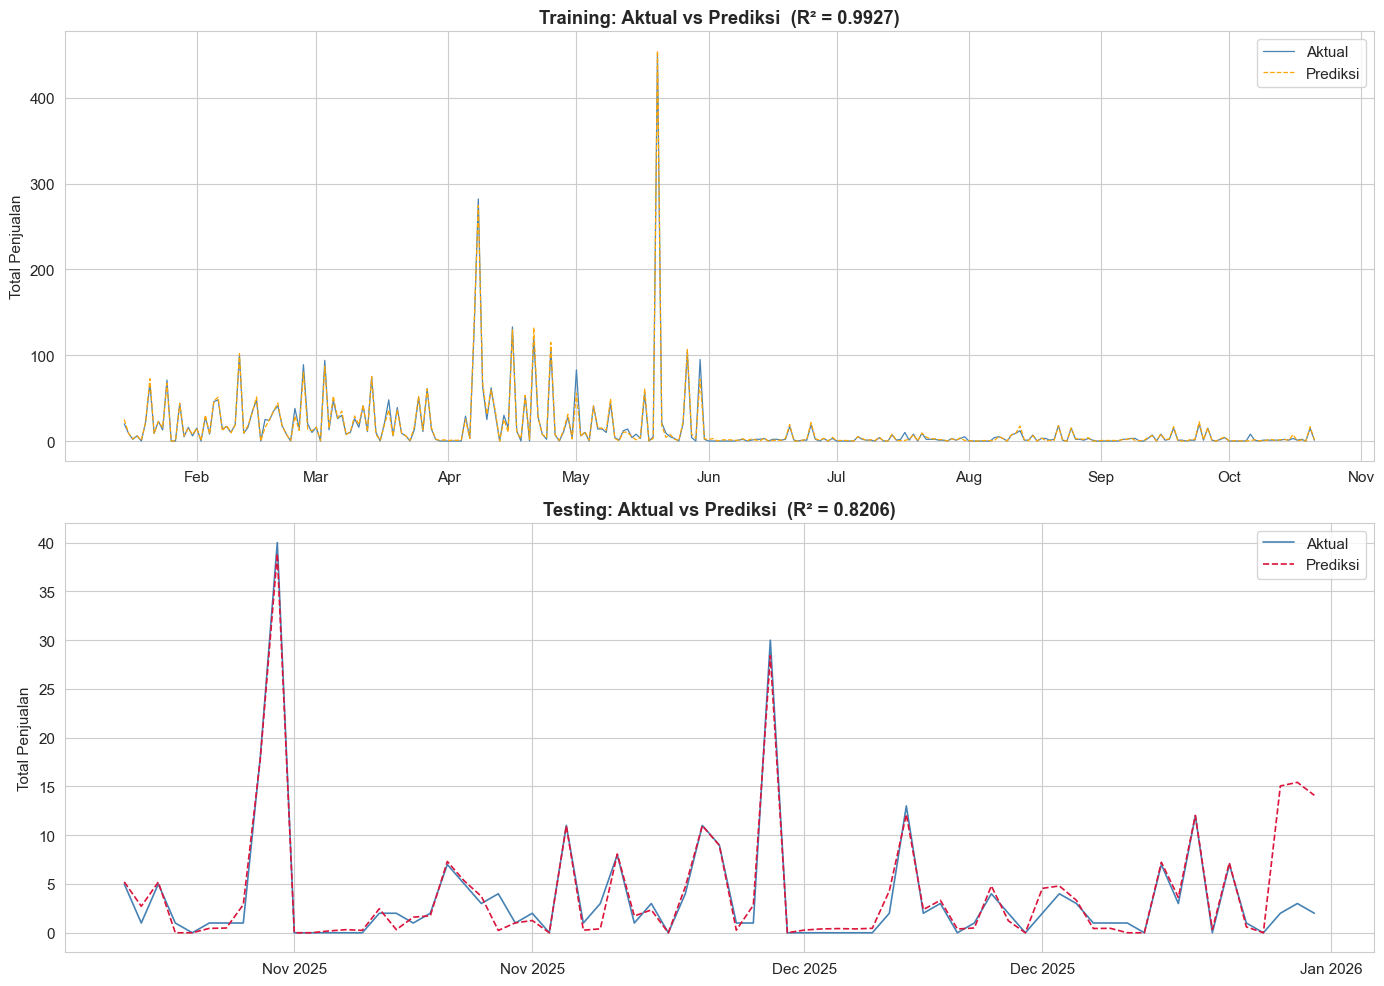

In [43]:
# Plot prediksi vs aktual (full)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Training
axes[0].plot(dates_train, y_train.values, label='Aktual', color='steelblue', linewidth=0.9)
axes[0].plot(dates_train, y_pred_train, label='Prediksi', color='orange', linewidth=0.9, linestyle='--')
axes[0].set_title(f'Training: Aktual vs Prediksi  (R² = {metrics_train["R2"]:.4f})', fontweight='bold')
axes[0].set_ylabel('Total Penjualan')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Testing
axes[1].plot(dates_test, y_test.values, label='Aktual', color='steelblue', linewidth=1.2)
axes[1].plot(dates_test, y_pred_test, label='Prediksi', color='crimson', linewidth=1.2, linestyle='--')
axes[1].set_title(f'Testing: Aktual vs Prediksi  (R² = {metrics_test["R2"]:.4f})', fontweight='bold')
axes[1].set_ylabel('Total Penjualan')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

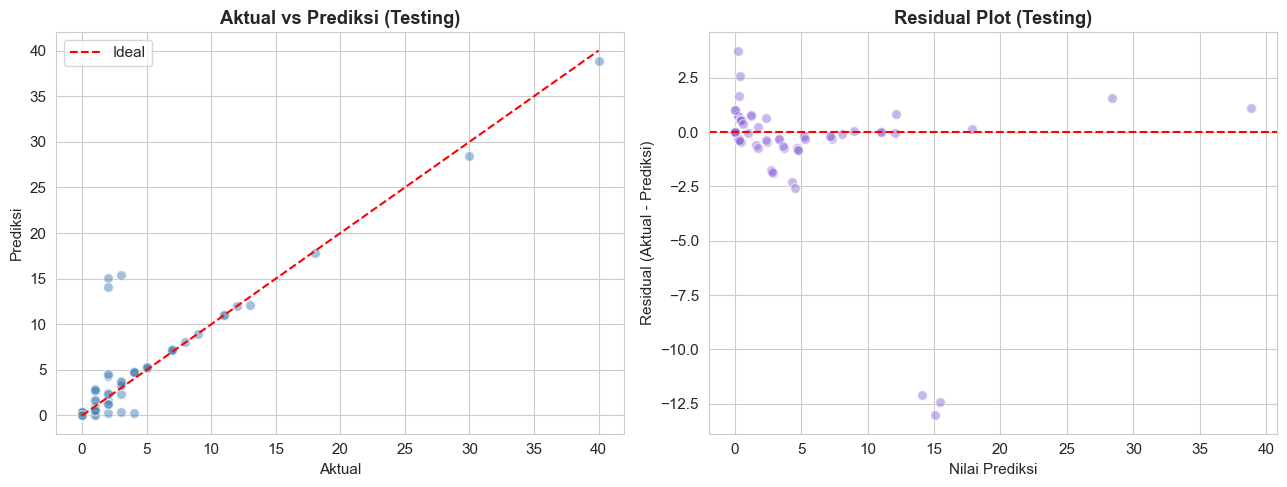

In [25]:
# Scatter plot: Aktual vs Prediksi (Test)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_test, y_pred_test, alpha=0.5, color='steelblue', edgecolors='white', s=50)
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ideal')
axes[0].set_xlabel('Aktual')
axes[0].set_ylabel('Prediksi')
axes[0].set_title('Aktual vs Prediksi (Testing)', fontweight='bold')
axes[0].legend()

# Residual plot
residuals = y_test.values - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.5, color='mediumpurple', edgecolors='white', s=50)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Nilai Prediksi')
axes[1].set_ylabel('Residual (Aktual - Prediksi)')
axes[1].set_title('Residual Plot (Testing)', fontweight='bold')

plt.tight_layout()
plt.show()

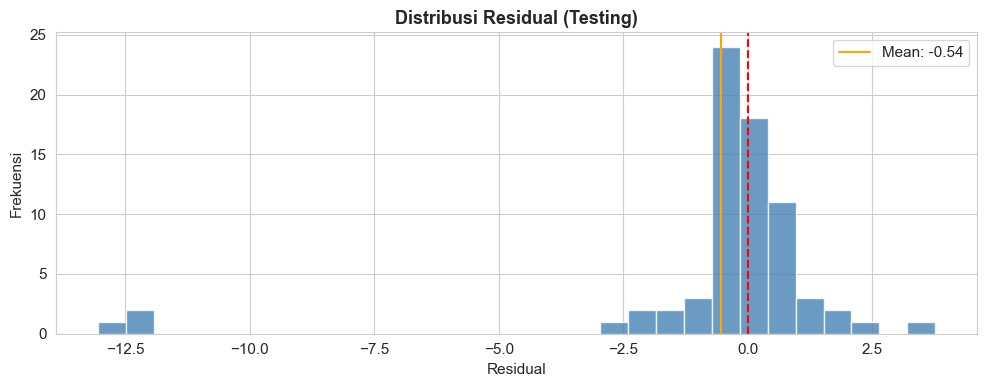

In [26]:
# Distribusi residual
plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.axvline(residuals.mean(), color='orange', linestyle='-', linewidth=1.5, label=f'Mean: {residuals.mean():.2f}')
plt.title('Distribusi Residual (Testing)', fontsize=13, fontweight='bold')
plt.xlabel('Residual')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Analisis Feature Importance (Koefisien Regresi)

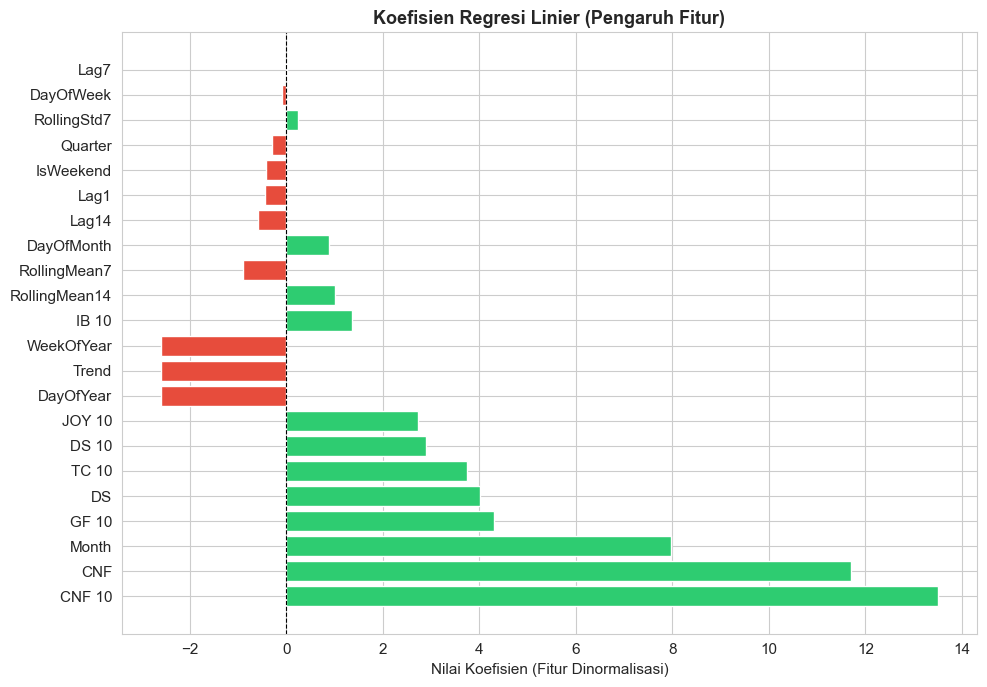


📋 Top 10 Fitur Paling Berpengaruh:
    Fitur  Koefisien
   CNF 10  13.508695
      CNF  11.697684
    Month   7.974154
    GF 10   4.308839
       DS   4.018708
    TC 10   3.739001
    DS 10   2.888388
   JOY 10   2.734732
DayOfYear  -2.601727
    Trend  -2.601727


In [27]:
# Koefisien model (setelah normalisasi = menunjukkan kepentingan relatif)
coef_df = pd.DataFrame({
    'Fitur': feature_cols,
    'Koefisien': model.coef_
}).sort_values('Koefisien', key=abs, ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in coef_df['Koefisien']]
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Koefisien Regresi Linier (Pengaruh Fitur)', fontsize=13, fontweight='bold')
plt.xlabel('Nilai Koefisien (Fitur Dinormalisasi)')
plt.tight_layout()
plt.show()

print('\n📋 Top 10 Fitur Paling Berpengaruh:')
print(coef_df.head(10).to_string(index=False))

## 10. Perbandingan Sampel Prediksi vs Aktual

In [28]:
# Tabel perbandingan 20 data pertama di set testing
comparison = pd.DataFrame({
    'Tanggal'  : dates_test.values[:20],
    'Aktual'   : y_test.values[:20].round(0).astype(int),
    'Prediksi' : y_pred_test[:20].round(0).astype(int),
    'Selisih'  : (y_test.values[:20] - y_pred_test[:20]).round(0).astype(int),
    'Error %'  : np.where(
        y_test.values[:20] > 0,
        np.abs((y_test.values[:20] - y_pred_test[:20]) / y_test.values[:20] * 100).round(1),
        np.nan
    )
})
comparison['Tanggal'] = pd.to_datetime(comparison['Tanggal']).dt.strftime('%Y-%m-%d')
print('📋 Perbandingan Prediksi vs Aktual (20 Data Testing Pertama):')
comparison

📋 Perbandingan Prediksi vs Aktual (20 Data Testing Pertama):


,Tanggal,Aktual,Prediksi,Selisih,Error %
0,2025-10-22,5,5,0,4.3
1,2025-10-23,1,3,-2,171.8
2,2025-10-24,5,5,0,3.9
3,2025-10-25,1,0,1,100.0
4,2025-10-26,0,0,0,NaN
5,2025-10-27,1,0,1,54.8
6,2025-10-28,1,0,1,51.6
7,2025-10-29,1,3,-2,188.4
8,2025-10-30,18,18,0,0.9
9,2025-10-31,40,39,1,2.8


## 11. Ringkasan & Kesimpulan

In [29]:
print('=' * 55)
print('        RINGKASAN ANALISIS REGRESI LINIER')
print('=' * 55)
print(f'  Dataset       : Pivot_Harian_ARIMA (365 hari)')
print(f'  Target        : Total_Sales')
print(f'  Jumlah Fitur  : {len(feature_cols)}')
print(f'  Train/Test    : {split_idx}/{len(y_test)} baris (80/20)')
print()
print('  ── PERFORMA TESTING ──')
print(f'  R²   : {metrics_test["R2"]*100:.2f}%')
print(f'  MAE  : {metrics_test["MAE"]:.2f} unit')
print(f'  RMSE : {metrics_test["RMSE"]:.2f} unit')
print(f'  MAPE : {metrics_test["MAPE"]:.2f}% (data non-zero)')
print()
print('  ── INTERPRETASI ──')
if metrics_test['R2'] >= 0.7:
    print('  ✅ Model cukup baik: R² ≥ 70%')
elif metrics_test['R2'] >= 0.5:
    print('  ⚠️  Model sedang: R² 50–70%')
else:
    print('  ❌ Model lemah: R² < 50% — pertimbangkan model lain')
print()
print('  Fitur paling berpengaruh:')
for _, row in coef_df.head(3).iterrows():
    print(f'    - {row["Fitur"]} (koef: {row["Koefisien"]:.2f})')
print('=' * 55)

        RINGKASAN ANALISIS REGRESI LINIER
  Dataset       : Pivot_Harian_ARIMA (365 hari)
  Target        : Total_Sales
  Jumlah Fitur  : 22
  Train/Test    : 280/71 baris (80/20)

  ── PERFORMA TESTING ──
  R²   : 82.06%
  MAE  : 1.13 unit
  RMSE : 2.74 unit
  MAPE : 73.63% (data non-zero)

  ── INTERPRETASI ──
  ✅ Model cukup baik: R² ≥ 70%

  Fitur paling berpengaruh:
    - CNF 10 (koef: 13.51)
    - CNF (koef: 11.70)
    - Month (koef: 7.97)
